In [1]:
import os
from tqdm import tqdm
import sys

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split

from pathlib import Path
import xarray as xr


In [2]:
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  from google.colab import drive
  drive.mount('/content/drive')

  os.chdir('/content/drive/MyDrive/colab_notebooks/projects')

  root_dir = Path(os.getcwd())
  data_dir = root_dir / 'data' / 'ca_imaging'
else:
  root_dir = Path(os.getcwd()).parent.parent.parent
  data_dir = root_dir / 'data' / 'ca_imaging'
  data_dir.mkdir(exist_ok=True, parents=True)

  import owncloud
  owncloud.Client.from_public_link('https://uni-bonn.sciebo.de/s/brt3t6FKkwnoTG3').get_file('/', data_dir / 'cells_data_all.nc')

if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))
data_dir = root_dir / 'data' / 'ca_imaging'

Mounted at /content/drive


In [3]:
#%load_ext autoreload
#%autoreload 2

In [4]:
from models.architectures.Unet import convbatchrelu, convdown, downsample, convup, upsample, Unet
from src.seed import set_seed, seed_worker, set_device
from src.data_pipeline.loaders.data_loaders import get_data_loaders
from src.data_pipeline.sourcing.downloaders.download_data import download_data
from src.data_pipeline.preprocessing.preprocess import normalize99

In [5]:
SEED = 2025
set_seed(seed=SEED)
DEVICE = set_device()

Random seed 2025 has been set.
GPU is enabled in this notebook.


### Load Dataset

In [6]:
data_dir.mkdir(exist_ok=True, parents=True)

import owncloud

owncloud.Client.from_public_link('https://uni-bonn.sciebo.de/s/brt3t6FKkwnoTG3').get_file('/', data_dir / 'cells_data_all.nc')

ModuleNotFoundError: No module named 'owncloud'

Create data class

In [7]:
class CellsDataset(Dataset):
    def __init__(self) -> None:
        super(CellsDataset, self).__init__()

        # load dataset
        dataset = xr.load_dataset(data_dir / 'cells_data_all.nc')

        # extract images and labels from dataset
        self.images = torch.from_numpy(dataset['ca_image_data'].values).float()
        self.labels = torch.from_numpy(dataset['cell_labels'].values).float()

    def __len__(self):
        """Get the number of images in dataset"""
        return len(self.images)

    def __getitem__(self, index):
        """Get a specific image and its cell labels"""
        return self.images[index], self.labels[index]

Load cell data class

In [8]:
cells_data = CellsDataset()

Split data into train, validation, and test sets

In [9]:
train_proportion = 0.7
val_proportion = 0.15

train_size = int(train_proportion*len(cells_data))
val_size = int(val_proportion*len(cells_data))
test_size = len(cells_data) - train_size - val_size

train_data, val_data, test_data = random_split(cells_data, [train_size, val_size, test_size])

Create dataloader for each dataset.

In [49]:
g_seed = torch.Generator().manual_seed(SEED)

train_dataloader = DataLoader(train_data, shuffle=True, batch_size=8, generator=g_seed)
val_dataloader = DataLoader(val_data, shuffle=True, batch_size=8, generator=g_seed)
test_dataloader = DataLoader(test_data, shuffle=True, batch_size=len(train_data), generator=g_seed)

Visualize example image from training data

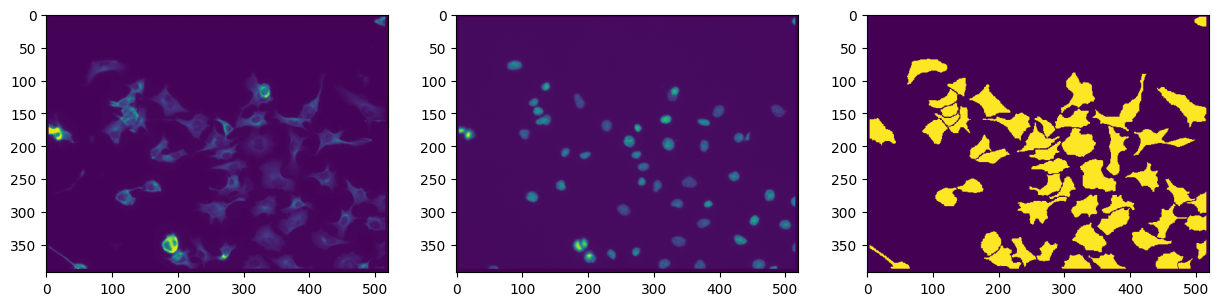

In [50]:
train_images_batch, train_labels_batch = next(iter(train_dataloader))

fig, axes = plt.subplots(ncols=3, figsize = (15,6))

image_nr = 1
axes[0].imshow(train_images_batch[image_nr,0])
axes[1].imshow(train_images_batch[image_nr,1])
axes[2].imshow(train_labels_batch[image_nr]);

### Define model

In [36]:
kernel_size = 3
nbase = [2, 32, 64, 128, 256]  # number of channels per layer
nout = 2  # number of outputs

model = Unet(nbase, nout, kernel_size)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device);

Train model

In [88]:
def train_model(model, dataloader, optimizer, loss_function = nn.CrossEntropyLoss(), device='cpu'):

    model.train()
    train_losses = 0
    #batch_accuracy = [] I'm not sure if I can calculate the accuracy during training because of gradients (with torch.no_grad()), that might be why they are splitting it up
    for batch_idx, (images, labels) in tqdm(enumerate(dataloader), desc='batch'):
        # Move data to the specified device
        images = images.to(device)
        labels = labels.to(device)

        #batch_accuracy.append(np.mean((labels == pred_labels).sum(axis=(1,2)) / labels[0].size))

        optimizer.zero_grad()

        output = model(images)

        loss = loss_function(output[:,0], labels)

        train_losses += (loss.item())

        loss.backward()

        optimizer.step()

    #train_accuracy = np.mean(batch_accuracy)
    train_losses /= len(dataloader)

    #print(f'Train accuracy {train_accuracy}')
    print(f'Train losses {train_losses}')

    return model, train_losses#, train_accuracy

def test_model(model, dataloader, loss_function = nn.CrossEntropyLoss(), device='cpu'):

    model.eval()
    with torch.no_grad():
        batch_accuracy = []
        loss = 0
        for batch_idx, (images, labels) in tqdm(enumerate(dataloader), desc='batch'):

            # Move data to the specified device
            images = images.to(device)
            labels = labels.to(device)

            output = model(images)

            loss += loss_function(output[:,0], labels).item()

            pred_labels = output[:,0].detach().cpu().numpy() > 0.5 # Move back to CPU for numpy conversion
            labels_acc = labels.detach().cpu().numpy() # Move back to CPU for numpy conversion

            batch_accuracy.append(np.mean((labels_acc == pred_labels).sum(axis=(1,2)) / labels_acc[0].size))

            print(f'Batch: {batch_idx}, loss: {loss_function(output[:,0], labels).item()}, batch accuracy: {batch_accuracy[-1]}')

        accuracy = np.mean(batch_accuracy)
        loss /= len(dataloader)

    return accuracy, loss

In [95]:
train_losses_lr, train_accuracies_lr = [], []
val_losses_lr, val_accuracies_lr = [], []

for learning_rate in [0.01]:

  model = Unet(nbase, nout, kernel_size)

  device = 'cuda' if torch.cuda.is_available() else 'cpu'
  model.to(device);

  nepochs = 7

  model.train()
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

  loss_function = nn.CrossEntropyLoss()

  train_losses, train_accuracies = [], []
  val_losses, val_accuracies = [], []
  for epoch in range(nepochs):

      model, train_loss = train_model(model, train_dataloader, optimizer, device=device)

      train_accuracy, train_loss = test_model(model, train_dataloader, device=device)
      val_accuracy, val_loss = test_model(model, val_dataloader, device=device)

      train_losses.append(train_loss)
      train_accuracies.append(train_accuracy)

      val_losses.append(val_loss)
      val_accuracies.append(val_accuracy)

  train_losses_lr.append(train_losses)
  train_accuracies_lr.append(train_accuracies)

  val_losses_lr.append(val_losses)
  val_accuracies_lr.append(val_accuracies)

batch: 8it [00:03,  2.03it/s]


Train losses 557.6194381713867


batch: 2it [00:00,  3.35it/s]

Batch: 0, loss: 18241.45703125, batch accuracy: 0.8530152325353217
Batch: 1, loss: 28468.666015625, batch accuracy: 0.6920108908948195


batch: 4it [00:01,  4.59it/s]

...

Batch: 4, loss: 347.0811767578125, batch accuracy: 0.9729683820643642
Batch: 5, loss: 505.03204345703125, batch accuracy: 0.9475256328492936


batch: 8it [00:01,  4.59it/s]


Batch: 6, loss: 314.1997375488281, batch accuracy: 0.9791294642857142
Batch: 7, loss: 305.25506591796875, batch accuracy: 0.9741954474097331


batch: 2it [00:00,  6.90it/s]

Batch: 0, loss: 677.2103271484375, batch accuracy: 0.936074249411303
Batch: 1, loss: 398.86688232421875, batch accuracy: 0.970633830455259


In [96]:
train_accuracies_lr[0]

[np.float64(0.7726919704179749),
 np.float64(0.7731786529000336),
 np.float64(0.8186747265011773),
 np.float64(0.953137822994926),
 np.float64(0.9524088286155808),
 np.float64(0.9626656367388988),
 np.float64(0.9647873332025118)]

In [99]:
from numpy._core.numeric import astype
model.eval()

with torch.no_grad():
  for val_images, val_labels in val_dataloader:
    test_images, test_labels = next(iter(test_dataloader))

    # Move data to the specified device
    val_images = val_images.to(device)
    val_labels = val_labels.to(device)

    output = model(val_images)

    pred_labels = (output[:,0].detach().cpu().numpy() > 0.5).astype(int)

    val_accuracy = (val_labels.cpu().detach().numpy() == pred_labels).sum(axis=(1,2)) / val_labels.cpu().detach().numpy()[0].size
    print(val_accuracy.mean())


0.962656372645212
0.9281024332810048


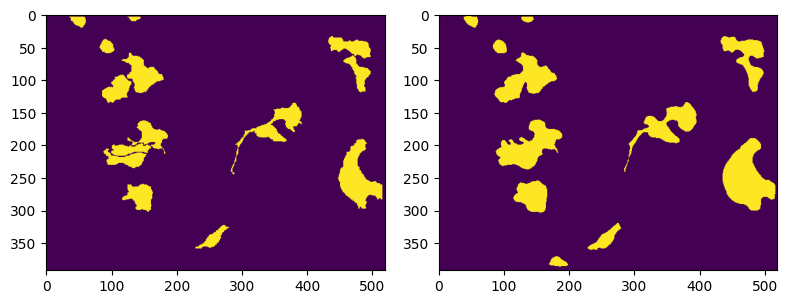

In [108]:
fig, axes = plt.subplots(ncols = 2, figsize = (8,12))

val_labels_plot = val_labels.cpu().detach().numpy()

image_nr = 4
axes[0].imshow(val_labels_plot[image_nr])
axes[1].imshow(pred_labels[image_nr])

fig.tight_layout()